### Import Libraries

In the first step, I import the necessary libraries to support the processes of data analysis, preprocessing, and building the house price prediction model.

- `pandas` and `numpy` are used for data manipulation and numerical operations.  
- `seaborn` and `matplotlib` are used for data visualization.  
- `train_test_split` is used to split the dataset into training and testing sets.  
- `SimpleImputer` is used to handle missing values.  
- `OneHotEncoder` and `StandardScaler` are used for encoding categorical variables and scaling numerical features.  
- `LinearRegression` is the linear regression model used for training.  
- The functions in `sklearn.metrics` are used to evaluate the model performance.  

In [ ]:

import pandas as pd 
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load Dataset

In [18]:
#Load Dataset
data=pd.read_csv("train-house-prices-advanced-regression-techniques.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [21]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Distribution of SalePrice and Missing Values

In this step, I visualize the distribution of the target variable `SalePrice` and examine the percentage of missing values in the dataset.

First, I plot a histogram with a KDE curve for `SalePrice` to better understand its distribution. This helps identify whether the target variable is normally distributed or skewed, which is important when deciding whether a transformation such as `log1p` is needed.

Next, I calculate the percentage of missing values for each column and display the top 20 columns with the highest missing rates using a bar chart. This allows me to detect which features contain a large amount of missing data and may require special preprocessing methods such as imputation or replacement.

This step provides an initial understanding of both the target variable and the data quality of the dataset.

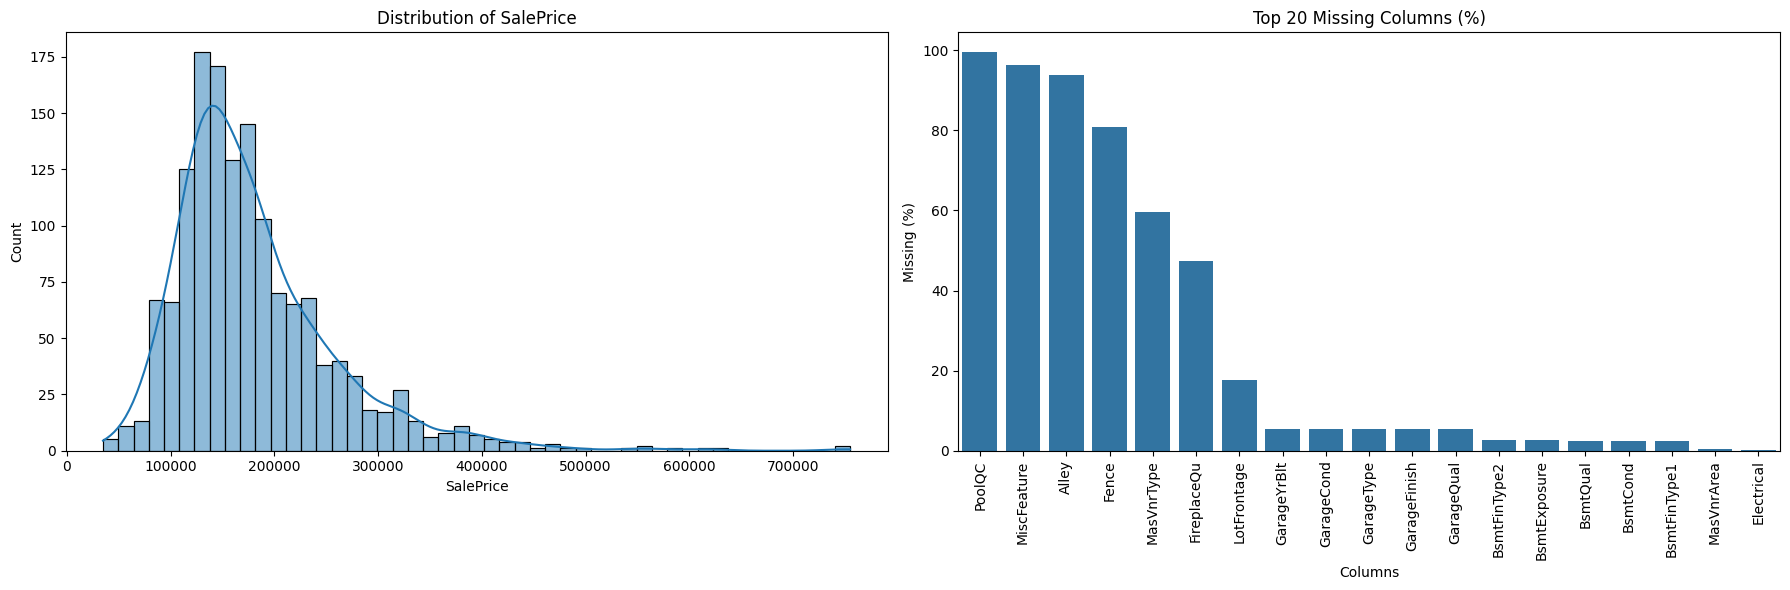

In [ ]:
target_col = 'SalePrice'   

missing_percent = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0].head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(data[target_col].dropna(), kde=True, ax=axes[0])
axes[0].set_title(f'Distribution of {target_col}')
axes[0].set_xlabel(target_col)
axes[0].set_ylabel('Count')

sns.barplot(x=missing_percent.index, y=missing_percent.values, ax=axes[1])
axes[1].set_title('Top 20 Missing Columns (%)')
axes[1].set_xlabel('Columns')
axes[1].set_ylabel('Missing (%)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Correlation Heatmap of Top Numerical Features

In this step, I analyze the correlation between numerical features and the target variable `SalePrice`.

First, I select only the numeric columns from the dataset. Then, I compute the correlation matrix and identify the top 10 features that have the strongest absolute correlation with `SalePrice`. These selected features are then visualized using a heatmap.

The heatmap helps me observe which numerical variables are most strongly related to house price. It also shows the relationships among the important features themselves, which is useful for identifying multicollinearity.

This step supports feature selection and provides insight into which numerical variables may contribute most to the prediction of house prices.

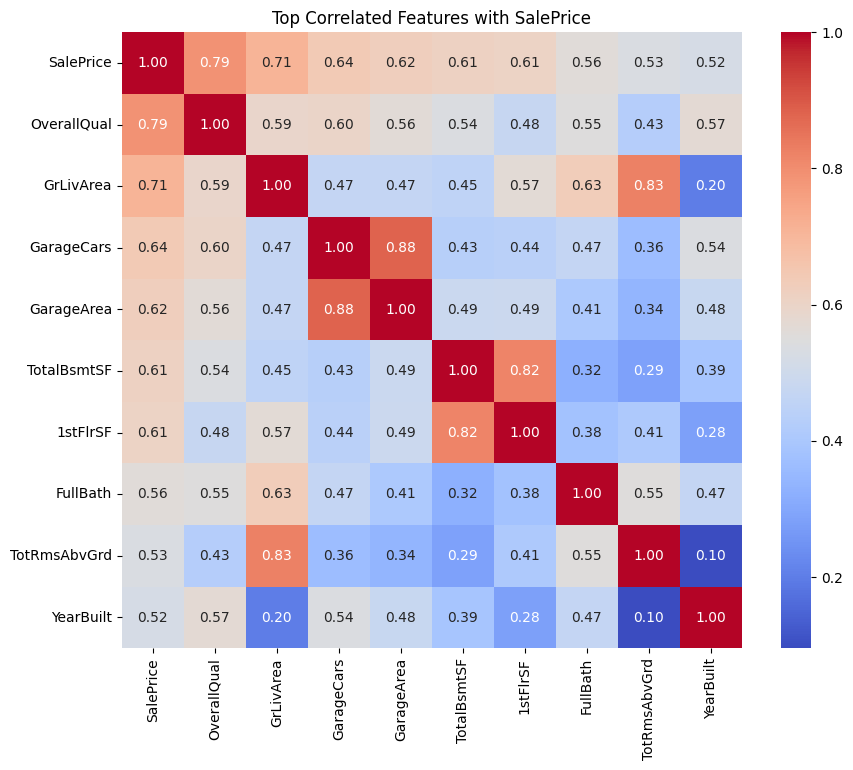

In [23]:
numeric_data = data.select_dtypes(include=[np.number])

top_corr_features = numeric_data.corr()[target_col].abs().sort_values(ascending=False).head(10).index

top_corr_matrix = numeric_data[top_corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'Top Correlated Features with {target_col}')
plt.show()

### Applying `log1p` to the Target Variable

In this step, I apply the `log1p` transformation to the target variable `SalePrice`.

- `log1p` computes `log(1 + x)`, which helps avoid issues when the variable contains zero values, since `SalePrice` can be equal to 0.
- It is commonly used to reduce skewness in numerical data.
- This is useful when the target variable has a long right tail or contains very large values.
- I create a new column called `SalePrice_log` by applying `np.log1p()` to `SalePrice`.
- Then, I compare the distribution before and after the transformation using two histograms.
- After transformation, the target variable becomes more balanced and closer to a normal distribution.
- This helps linear regression models learn more effectively and may improve prediction performance.

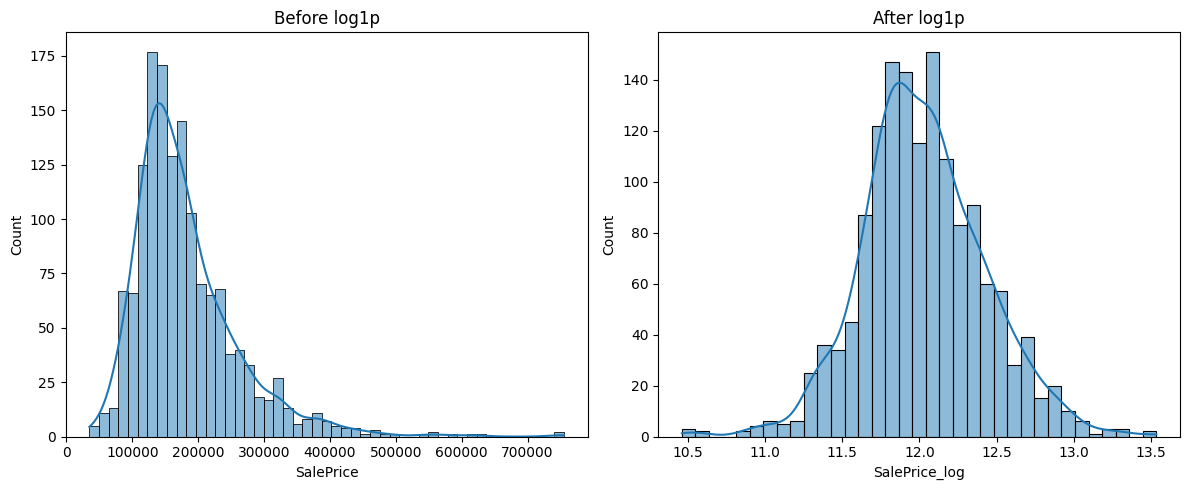

In [24]:
data['SalePrice_log'] = np.log1p(data[target_col])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data[target_col], kde=True, ax=axes[0])
axes[0].set_title('Before log1p')

sns.histplot(data['SalePrice_log'], kde=True, ax=axes[1])
axes[1].set_title('After log1p')

plt.tight_layout()
plt.show()

In [25]:
X = data.drop(columns=[target_col])
y = np.log1p(data[target_col])   
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Handling Missing Values

In this step, I preprocess the missing values in the training and testing sets.

First, I define a list of categorical columns in which missing values indicate the absence of a feature rather than an unknown value. For these columns, I replace missing values with `"None"` in both `X_train` and `X_test`.

Next, I handle some specific columns using different strategies. I fill missing values in `Electrical` with the mode because it is a categorical variable. I fill missing values in `LotFrontage` with the median because it is a numerical variable and the median is less sensitive to outliers. I also replace missing values in `MasVnrArea` and `GarageYrBlt` with `0`, since these missing values usually represent the absence of masonry veneer area or garage construction year information.

This step is important because machine learning models cannot work properly when missing values are left untreated.

In [36]:
data.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageCond        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [26]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtQual",
    "BsmtCond",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

for col in none_cols:
    X_train[col] = X_train[col].fillna("None")
    X_test[col] = X_test[col].fillna("None")

electrical_mode = X_train["Electrical"].mode()[0]
lotfrontage_median = X_train["LotFrontage"].median()

X_train["Electrical"] = X_train["Electrical"].fillna(electrical_mode)
X_test["Electrical"] = X_test["Electrical"].fillna(electrical_mode)

X_train["MasVnrArea"] = X_train["MasVnrArea"].fillna(0)
X_test["MasVnrArea"] = X_test["MasVnrArea"].fillna(0)

X_train["GarageYrBlt"] = X_train["GarageYrBlt"].fillna(0)
X_test["GarageYrBlt"] = X_test["GarageYrBlt"].fillna(0)

X_train["LotFrontage"] = X_train["LotFrontage"].fillna(lotfrontage_median)
X_test["LotFrontage"] = X_test["LotFrontage"].fillna(lotfrontage_median)

### Preparing Categorical and Numerical Features

In this step, I prepare the dataset for feature transformation by separating categorical features from numerical features and initializing the encoder.

- First, I identify the categorical columns in `X_train` by selecting features stored as `object` or `category`.
- Then, I identify the numerical columns by selecting features stored in numeric format.
- This separation is important because categorical and numerical variables need different preprocessing methods.
- Numerical features can be used directly after scaling, while categorical features must be converted into a machine-readable format.
- After that, I initialize `OneHotEncoder` to transform the categorical features into binary columns.
- I set `handle_unknown="ignore"` so that the encoder can still process the test set even if it contains categories that were not present in the training set.
- At this stage, I am preparing the structure needed to convert all input features into a usable format for the regression model.

In [27]:
X_train = X_train.drop("Id", axis=1)
X_test = X_test.drop("Id", axis=1)



In [30]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [ ]:
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

X_train = pd.concat([X_train[num_cols], X_train_cat_df], axis=1)
X_test = pd.concat([X_test[num_cols], X_test_cat_df], axis=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training and Evaluating the Linear Regression Model

In this step, I train the Linear Regression model and evaluate its performance on the test set.

- First, I create a `LinearRegression()` model and fit it using the scaled training data `X_train_scaled` and the transformed target variable `y_train`.
- After the model is trained, I use it to predict the target values for the scaled test set `X_test_scaled`.
- The predictions at this stage are still on the log-transformed scale, so I evaluate them first using `RMSE`, `MAE`, and `R²` on the log scale.
- Then, I convert both `y_test` and the predicted values back to the original price scale using `np.expm1()`.
- This allows me to measure the model performance in terms of the actual house prices, which is easier to interpret in a real-world context.
- Finally, I calculate `RMSE`, `MAE`, and `R²` again on the original price scale and print the results.
- This step helps assess how well the Linear Regression model performs both on the transformed target and on the actual house price values.

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


y_pred_log = model.predict(X_test_scaled)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

print("=== Evaluation on log scale ===")
print("RMSE_log:", rmse_log)
print("MAE_log :", mae_log)
print("R2_log  :", r2_log)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae_real = mean_absolute_error(y_test_real, y_pred_real)
r2_real = r2_score(y_test_real, y_pred_real)

print("\n=== Evaluation on original price scale ===")
print("RMSE:", rmse_real)
print("MAE :", mae_real)
print("R2  :", r2_real)

=== Evaluation on log scale ===
RMSE_log: 2.1023278364688262e-15
MAE_log : 1.5756041828926879e-15
R2_log  : 1.0

=== Evaluation on original price scale ===
RMSE: 3.8790603004213746e-10
MAE : 2.707802444977099e-10
R2  : 1.0
